In [1]:
import sys
import os

sys.path.append('/home/paule/open_mc_projects/windowed_multipole/02_working_notebook_vectfit')
sys.path.append('/home/paule/open_mc_projects/xs_lib/endfb-vii.1-hdf5/neutron')
sys.path.append('/home/paule/open_mc_projects/MC-1D_DT')


from src.neutron_class import Neutron
from src.source_class import Source, _BatchSource, SourceRegion
from src.geometry_classes import Geometry, Material, Region
import src.geometry_classes as geom
import src.performance_classes as perf
import src.tally_classes as tally
import src.vectfit as vf
import src.export_simulation_v3 as xpsim
import src.export_print_csv as xpcsv
import src.reconr_v2 as reconr
import src.parallel as parallel

import openmc

openmc.config['cross_sections'] = "/home/paule/open_mc_projects/xs_lib/endfb-vii.1-hdf5/cross_sections.xml"





['/home/paule/anaconda3/envs/vectfit39/lib/python39.zip', '/home/paule/anaconda3/envs/vectfit39/lib/python3.9', '/home/paule/anaconda3/envs/vectfit39/lib/python3.9/lib-dynload', '', '/home/paule/anaconda3/envs/vectfit39/lib/python3.9/site-packages', '/home/paule/open_mc_projects/windowed_multipole/02_working_notebook_vectfit', '/home/paule/open_mc_projects/xs_lib/endfb-vii.1-hdf5/neutron', '/home/paule/open_mc_projects/MC-1D_DT', '/home/paule/open_mc_projects/windowed_multipole/02_working_notebook_vectfit', '/home/paule/open_mc_projects/windowed_multipole/02_working_notebook_vectfit']


In [2]:
# One slab of U238 — simple test case


# ============================================================================
# Uranium atom density
# ============================================================================
# Uranium metal density ~ 19.1 g/cm³,
# N = rho * Na / A  (atoms/cm³)
rho_U   = 19.1               # g/cm³
NA      = 6.02214076e23      # atoms/mol

x_U235 = 0.00                # 0% enrichment
x_U238 = 1.0 - x_U235

M_U8   = 238.05078826        # g/mol
M_U5   = 235.0439299         # g/mol
N_total_U8 = rho_U * NA / (x_U238 * M_U8 + x_U235 * M_U5)
N_total_U5 = rho_U * NA / (x_U235 * M_U5 + x_U238 * M_U8)

N_U235 = 1.0 * N_total_U5   # 0%  enrichment
N_U238 = 1.0 * N_total_U8   # 100%

slab1 = Material(
    name     = "cell 1",
    nuclides = [('U238', N_U238)],
    T        = 293.6,    # K (~20 °C)
)

slab2 = Material(
    name     = "cell 2",
    nuclides = [('U238', N_U238)],
    T        = 2000,     # K
)


[Material] Processing nuclide pair: U238 (Density: 4.83e+22)
[Material] Processing nuclide pair: U238 (Density: 4.83e+22)


In [ ]:
# ============================================================================
# Geometry  (two slabs)
# ============================================================================
geom = Geometry(majorant_log=True, poll_interval=0.001, verbose=False)

# ── Materials ────────────────────────────────────────────────────────────────
geom.add_material(slab1)
geom.add_material(slab2)

# ── Regions (replaces manual boundaries + material_array assignment) ─────────
geom.add_region(name="slab1", material=slab1, x_min=0.0,  x_max=2.0)
geom.add_region(name="slab2", material=slab2, x_min=2.0,  x_max=15.0)
geom.set_boundary_conditions("reflective", "reflective")

# ── Tallies ──────────────────────────────────────────────────────────────────
energy_bins = [10.0, 50.0, 600.0, 1e4, 1e6, 2e7]  # eV
geom.attach_flux_tally(energy_bins)
geom.attach_verification_tally(
    energy_bins = energy_bins,
    surface_xs  = [0.0, 2.0, 15.0],
)

# ── Majorant and XS method ───────────────────────────────────────────────────
geom.maj_mat_method = "simple"
geom.set_maj_xs_method(
    method  = "sqrtT_E",
    T_array = [0, 293, 500, 1000, 1500, 1900, 2000],
)
geom.set_access_method("fly", last_energy=600, err_lim=0.0001, err_max=0.001)
geom.set_mode("analysis", filename="validation/xs_generation/statepoint.200.h5")

# -- Cutoff energies
geom.set_cutoff_energy(70.0)  # eV

# ============================================================================
# Source
# ============================================================================
N_NEUTRONS = 20000
N_BATCHES  = 50

src = Source.point(
    neutron_nbr    = N_NEUTRONS,
    geometry       = geom,
    region_name    = "slab1",
    position       = [0.0, 0.0, 0.0],
    energy_dist    = "mono",
    energy_range   = (500, 500),
    direction_dist = "forward",
    direction      = [1.0, 0.0, 0.0],
)


 [Memory] Tracker started (poll interval: 1 ms)

 [Memory] Tracker stopped.

 [Memory] Tracker started (poll interval: 1 ms)

 [Memory] Tracker stopped.
[Setup] Boundary conditions set: left='reflective', right='reflective'
15.0

 [Memory] Tracker started (poll interval: 1 ms)

 [Memory] Tracker stopped.

 [Memory] Tracker started (poll interval: 1 ms)
Loading table from: /home/paule/open_mc_projects/MC-1D_DT/structured_code/src/sqrtT_E_data
  [Setup] T Bounds for sqrtT_E set: 293.6 K to 2000 K

 [Memory] Tracker stopped.

 [Memory] Tracker started (poll interval: 1 ms)

 [Memory] Tracker stopped.

 [Memory] Tracker started (poll interval: 1 ms)

 [Memory] Tracker stopped.


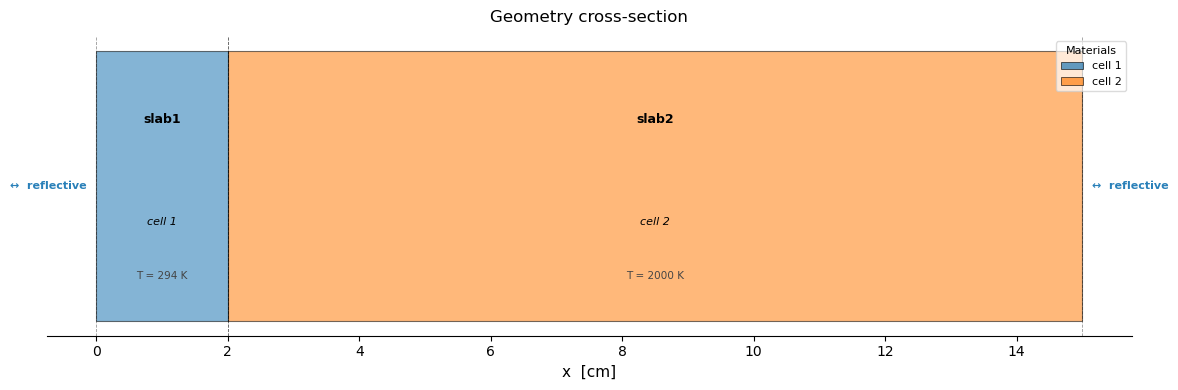

(<Figure size 1200x400 with 1 Axes>,
 <Axes: title={'center': 'Geometry cross-section'}, xlabel='x  [cm]'>)

In [5]:
geom.draw()

In [6]:
batch_stats = geom.run_batch(src, n_batches=N_BATCHES, n_workers=20, mode="parallel")
print(f"mode: {geom.mode}")
print(f"majorant XS method: {geom.maj_xs_method}")
print(f"majorant material method: {geom.maj_mat_method}")
print(f"access method: {geom.access_method}")
print(geom.summary())

#xpcsv.export_cross_batch_stats(batch_stats, geom=geom, print_to_console= False, save_csv= True, output_dir=f'cross_batch_stats_{geom.maj_xs_method}_{geom.maj_mat_method}_reconr_v2_new.csv')




 [Memory] Tracker started (poll interval: 1 ms)

[Parallel] Running 50 batches on 20 workers...



[Simulation] Running source (Mode: analysis)

[Simulation] Running source (Mode: analysis)
[Simulation] Running source (Mode: analysis)


[Simulation] Running source (Mode: analysis)

[Simulation] Running source (Mode: analysis)

[Simulation] Running source (Mode: analysis)

[Simulation] Running source (Mode: analysis)

[Simulation] Running source (Mode: analysis)

[Simulation] Running source (Mode: analysis)

[Simulation] Running source (Mode: analysis)

[Simulation] Running source (Mode: analysis)

[Simulation] Running source (Mode: analysis)

[Simulation] Running source (Mode: analysis)

[Simulation] Running source (Mode: analysis)

[Simulation] Running source (Mode: analysis)

[Simulation] Running source (Mode: analysis)

[Simulation] Running source (Mode: analysis)

[Simulation] Running source (Mode: analysis)

[Simulation] Running source (Mode: analysis)

[Simulation] Running source (Mode: analysis)

[Simulation] Running source (Mode: analysis)

[Simulation] Running source (Mode

In [7]:
import src.export_print_csv as xpcsv
xpcsv.export_cross_batch_stats(batch_stats, geom=geom, print_to_console= True)


  CROSS-BATCH STATISTICS

  FLUX TALLY [cm · src-n⁻¹]
  Group                               Mean           ±Std    Rel.Err
  -----------------------------------------------------------------
  10-50 eV                      0.0000e+00     0.0000e+00        inf
  50-600 eV                     2.5930e+01     2.3967e-02     0.0009
  600-10000 eV                  0.0000e+00     0.0000e+00        inf
  10000-1000000 eV              0.0000e+00     0.0000e+00        inf
  1000000-20000000 eV           0.0000e+00     0.0000e+00        inf

  ABSORPTION RATE [reactions · src-n⁻¹]
  Region / Group                      Mean           ±Std    Rel.Err
  -----------------------------------------------------------------
  0.0-2.0 cm | 10-50 eV         0.0000e+00     0.0000e+00        inf
  0.0-2.0 cm | 50-600 eV        2.6190e-01     4.1464e-04     0.0016
  0.0-2.0 cm | 600-10000 eV     0.0000e+00     0.0000e+00        inf
  0.0-2.0 cm | 10000-1000000 eV     0.0000e+00     0.0000e+00        inf
  0.0

  MEMORY TRACKER SUMMARY
  Baseline RSS          : 2.107e+02 MB
  Peak RSS (continuous) : 2.256e+02 MB
  Total growth          : +1.491e+01 MB
-----------------------------------------------------------------
  Label                         RSS (MB)  Delta (MB)  Time (s)
-----------------------------------------------------------------
  init                             210.7        +0.0     0.002
  add_material_cell 1              210.7        +0.0     0.003
  stop                             210.7        +0.0     0.003
  init                             210.7        +0.0     0.004
  add_material_cell 2              210.7        +0.0     0.004
  stop                             210.7        +0.0     0.006
  init                             210.7        +0.0     0.007
  maj_mat_method_setup             210.7        +0.0     0.007
  stop                             210.7        +0.0     0.008
  init                             210.7        +0.0     0.009
  maj_xs_method_setup           

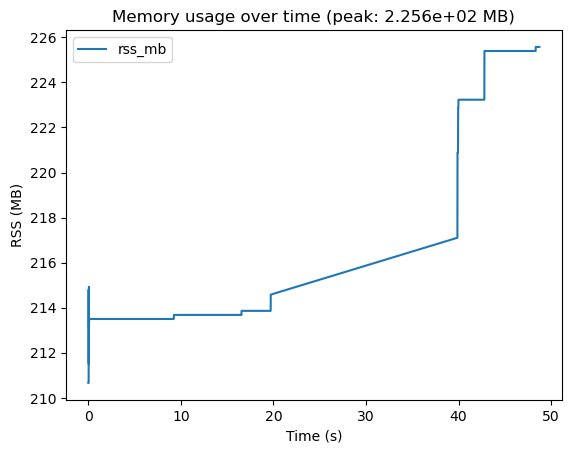

In [ ]:
print(geom.memory_summary())
df_poll_2 = geom.memory.poll_to_dataframe()
figure, ax = plt.subplots()
df_poll_2.plot(x="time_s", y="rss_mb", ax=ax)
ax.set_title(f"Memory usage over time (peak: {max(df_poll_2['rss_mb']):.3e} MB)")
ax.set_xlabel("Time (s)")
ax.set_ylabel("RSS (MB)")
print(df_poll_2.head())
print(max(df_poll_2["rss_mb"]))
print(df_poll_2[df_poll_2["rss_mb"] == max(df_poll_2["rss_mb"])]["time_s"].values[0])

In [ ]:
#xpsim.export_simulation(geom, batch_stats, print_to_console=False, save_csv=True, output_dir=f'simulation_output_{geom.maj_xs_method}_{geom.maj_mat_method}_{geom.access_method}.csv')
xpcsv.export_cross_batch_stats(batch_stats, geom=geom, print_to_console= False, save_csv= True, output_dir=f'cross_batch_stats_{geom.maj_xs_method}_{geom.maj_mat_method}_{geom.access_method}.csv')


Cross-batch statistics saved → cross_batch_stats_vectfit_simple_reconr.csv
